
# Miejsce tego notebooka w planie 3h/4h

Ten notebook jest pierwszą częścią spotkania 3h. Jego rola to **domknięcie ostatnich tematów**, a nie wejście w nową rodzinę modeli.

Najważniejsze elementy do zrobienia na żywo:

1. $\bar y$ vs $\hat y$ vs $\hat p$,
2. baseline i $R^2$,
3. probability, odds, log-odds,
4. threshold,
5. FP/FN na danych nieczystych.

Sekcja LDA w tym notebooku jest tylko **krótkim mostem / zapowiedzią**. Pełniejsze LDA/QDA lepiej wróci w atlasie granic po drzewach i Random Forest.

Jeżeli brakuje czasu, nie robić LDA tutaj — przejść do drzew.


## Wspólna historia tej części

Ten notebook jest pomostem między poprzednim wykładem a drzewami.

Chcemy uporządkować trzy rzeczy:

$$
\bar y \quad \rightarrow \quad \hat y \quad \rightarrow \quad \hat p
$$

czyli:

- $
\bar y$ — średnia, baseline dla regresji,
- $
\hat y$ — predykcja modelu lub twarda klasa,
- $
\hat p$ — prawdopodobieństwo klasy pozytywnej.

Potem przechodzimy do decyzji:

$$
\hat y = I(\hat p \ge t)
$$

To przygotowuje studentów do drzew, bo drzewo też podejmuje decyzje przez progi — tylko progi są wybierane automatycznie.

## Ważne rozróżnienie: model, score i decyzja

W klasyfikacji często mieszają się trzy poziomy:

| Poziom | Symbol | Przykład |
|---|---:|---|
| score / logit | $z=b_0+b_1x$ | $z=0.7$ |
| prawdopodobieństwo | $\hat p=\sigma(z)$ | $\hat p=0.668$ |
| decyzja | $\hat y=I(\hat p \ge t)$ | dla $t=0.5$: $\hat y=1$ |

Ten sam model może mieć te same prawdopodobieństwa, ale inne decyzje, gdy zmienimy próg $t$.
Dlatego confusion matrix zależy od progu.

# Wykład 4 — część 0: domknięcie wykładu 3, $\bar y$, $\hat y$, $R^2$, log-odds i LDA

Ten notebook jest krótkim **pomostem** między materiałem z wykładu 3 a kolejnymi algorytmami.

W notatkach po wykładzie pojawiła się ważna obserwacja: studenci muszą wyraźnie odróżniać dwa symbole:

$$
\bar y \quad \text{oraz} \quad \hat y
$$

To odróżnienie prowadzi przez całą resztę kursu:

$$
\bar y \rightarrow \text{baseline} \rightarrow R^2 \rightarrow \hat y \rightarrow \text{model}
$$

W części klasyfikacyjnej podobną rolę pełni przejście:

$$
P(Y=1\mid X) \rightarrow odds \rightarrow log\text{-}odds \rightarrow threshold
$$

Na końcu dodajemy **LDA** jako krótki, statystyczny most między regresją logistyczną a modelami geometrycznymi.

## Mapa logiczna

| Krok | Pytanie | Pojęcie |
|---|---|---|
| 1 | Co robi najprostszy model regresji? | przewiduje $\bar y$ |
| 2 | Co robi lepszy model? | przewiduje $\hat y_i=f(x_i)$ |
| 3 | Jak porównać model z baseline'em? | $R^2$ |
| 4 | Jak przejść z regresji do klasyfikacji? | $Passed=I(Grade\ge 50)$ |
| 5 | Dlaczego logit jest wygodny? | log-odds żyje na całej osi |
| 6 | Co robi threshold? | zamienia probability na decyzję |
| 7 | Gdzie pasuje LDA? | liniowa granica z założeń o rozkładach klas |

Rytm dydaktyczny w tym notebooku jest celowo powtarzalny:

$$
\text{teoria} \rightarrow \text{mały przykład} \rightarrow \text{kod} \rightarrow \text{interpretacja}
$$

## Jak prowadzić tę część na zajęciach?

Ten notebook warto prowadzić jako **powrót do symboli**, nie jako kolejny nowy algorytm. Najpierw można na tablicy zapisać cztery obiekty, które często mieszają się studentom:

| Symbol | Znaczenie | Skąd pochodzi? |
|---|---|---|
| $y_i$ | prawdziwa wartość dla obserwacji $i$ | dane |
| $\bar y$ | średnia wartość targetu | baseline / opis danych |
| $\hat y_i$ | predykcja modelu dla obserwacji $i$ | model regresyjny |
| $\hat p_i$ | przewidywane prawdopodobieństwo klasy 1 | model klasyfikacyjny |

Dopiero po takim rozróżnieniu metryki przestają być listą wzorów. Wtedy $R^2$ można opowiedzieć jako pytanie:

$$
\text{czy } \hat y_i \text{ jest lepsze niż } \bar y?
$$

A klasyfikację logistyczną jako pytanie:

$$
\text{jak zamienić liniowy wynik modelu na prawdopodobieństwo z przedziału } [0,1]?
$$

## Przykład słowny: średnia, predykcja i decyzja

Załóżmy, że pytamy o ocenę studenta. Jeśli nie wiemy nic o liczbie godzin nauki, rozsądny pierwszy strzał to średnia:

$$
\hat y = \bar y
$$

To nie jest „głupi” model. To punkt odniesienia. Dopiero kiedy znamy `StudyHours`, możemy powiedzieć:

$$
\hat y_i = b_0 + b_1 StudyHours_i
$$

Jeśli natomiast pytanie brzmi „czy student zda?”, to model powinien zwrócić prawdopodobieństwo:

$$
\hat p_i = P(Passed_i=1\mid StudyHours_i)
$$

Ale prawdopodobieństwo nadal nie jest decyzją. Decyzja wymaga progu:

$$
\hat y_i = I(\hat p_i \ge t)
$$

To rozdzielenie jest bardzo ważne dydaktycznie:

```text
predykcja liczby ≠ prawdopodobieństwo ≠ decyzja klasyfikacyjna
```

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)


def find_data_file(filename):
    """Szukamy pliku w typowych lokalizacjach, żeby notebook działał po przeniesieniu."""
    candidates = [
        Path(filename),
        Path('data') / filename,
        Path('../data') / filename,
        Path('/mnt/data') / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'Nie znaleziono pliku: {filename}. Sprawdzone: {candidates}')


def regression_metrics(y_true, y_pred, label):
    return {
        'model': label,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'R2': r2_score(y_true, y_pred),
    }


def classification_metrics(y_true, y_pred, label):
    return {
        'model': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
    }

## 1. Dane `grades`: jeden zbiór, dwa pytania

Wykład 3 używał danych o liczbie godzin nauki i ocenie. Ten sam zbiór może być użyty do dwóch różnych zadań:

**Regresja:**

$$
Grade \approx f(StudyHours)
$$

**Klasyfikacja:**

$$
Passed = I(Grade \ge 50)
$$

To jest bardzo dobre dydaktycznie, bo studenci widzą, że problem ML nie wynika tylko z danych. Wynika też z pytania, które zadajemy.

In [3]:
grades_raw = pd.read_csv(find_data_file('previous_lecture_grades.csv'))
grades = grades_raw.dropna(subset=['StudyHours', 'Grade']).copy()
grades['Passed'] = (grades['Grade'] >= 50).astype(int)

display(grades.head())
print('Liczba obserwacji po usunięciu braków:', len(grades))
print('Rozkład Passed:')
display(grades['Passed'].value_counts().rename(index={0:'nie zdał', 1:'zdał'}))

,Name,StudyHours,Grade,Passed
0,Dan,10.00,50.0,1
1,Joann,11.50,50.0,1
2,Pedro,9.00,47.0,0
3,Rosie,16.00,97.0,1
4,Ethan,9.25,49.0,0


Liczba obserwacji po usunięciu braków: 22
Rozkład Passed:


zdał        11
nie zdał    11
Name: Passed, dtype: int64

## 2. $\bar y$ jako model zerowy

Średnia:

$$
\bar y = \frac{1}{n}\sum_{i=1}^n y_i
$$

nie jest tylko opisem danych. W modelowaniu jest też **baseline'em**:

$$
\hat y_i = \bar y_{train}
$$

Czyli model zerowy mówi:

> Nie patrzę na $x$. Każdemu przewiduję tę samą wartość: średnią z danych treningowych.

Dopiero model, który używa cech, próbuje robić coś lepszego:

$$
\hat y_i = f(x_i)
$$

In [4]:
from sklearn.linear_model import LinearRegression

X = grades[['StudyHours']]
y = grades['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Baseline: zawsze przewidujemy średnią ocenę z train.
y_bar_train = y_train.mean()
y_pred_baseline = np.full(shape=len(y_test), fill_value=y_bar_train)

# Model liniowy: przewidujemy ocenę na podstawie liczby godzin nauki.
lin = LinearRegression()
lin.fit(X_train, y_train)
y_pred_lin = lin.predict(X_test)

pd.DataFrame([
    regression_metrics(y_test, y_pred_baseline, 'baseline: zawsze średnia z train'),
    regression_metrics(y_test, y_pred_lin, 'regresja liniowa: StudyHours -> Grade'),
])

,model,MAE,RMSE,R2
0,baseline: zawsze średnia z train,24.952381,30.525222,-1.341419
1,regresja liniowa: StudyHours -> Grade,8.603574,11.205566,0.684478


### Jak czytać wynik?

- `MAE` mówi, o ile punktów średnio się mylimy.
- `RMSE` mocniej karze duże błędy, bo bazuje na kwadratach.
- $R^2$ porównuje model z baseline'em przewidującym średnią.

Ważne:

$$
R^2 = 1 - \frac{RSS}{TSS}
$$

gdzie:

$$
RSS = \sum_i (y_i - \hat y_i)^2
$$

oraz:

$$
TSS = \sum_i (y_i - \bar y)^2
$$

Jeśli $R^2<0$ na teście, to model jest gorszy niż przewidywanie średniej.

## 3. Mały przykład ręczny: skąd bierze się $R^2$?

Weźmy trzy wartości:


$$
y = [40, 50, 80]
$$

Średnia to:

$$
\bar{y} = \frac{40 + 50 + 80}{3} = \frac{170}{3} \approx 56.67
$$
Jeżeli model przewiduje:

$$
\hat y = [45, 55, 75]
$$

to porównujemy dwa błędy:

1. błąd baseline'u względem średniej,
2. błąd modelu względem predykcji.

In [5]:
y_toy = np.array([40, 50, 80])
y_hat_toy = np.array([45, 55, 75])
y_bar_toy = y_toy.mean()

TSS = np.sum((y_toy - y_bar_toy) ** 2)
RSS = np.sum((y_toy - y_hat_toy) ** 2)
R2_manual = 1 - RSS / TSS

pd.DataFrame({
    'y': y_toy,
    'y_bar': y_bar_toy,
    'y_hat': y_hat_toy,
    '(y-y_bar)^2': (y_toy - y_bar_toy) ** 2,
    '(y-y_hat)^2': (y_toy - y_hat_toy) ** 2,
})

,y,y_bar,y_hat,(y-y_bar)^2,(y-y_hat)^2
0,40,56.666667,45,277.777778,25
1,50,56.666667,55,44.444444,25
2,80,56.666667,75,544.444444,25


In [5]:
print('TSS =', TSS)
print('RSS =', RSS)
print('R2  =', R2_manual)

TSS = 866.6666666666667
RSS = 75
R2  = 0.9134615384615384


### Mini-wniosek

$R^2$ nie pyta tylko, czy model ma mały błąd. Pyta:

$$
\text{czy model ma mniejszy błąd niż zgadywanie średniej?}
$$

Dlatego $\bar y$ jest tak ważne. Bez średniej nie mamy naturalnego punktu odniesienia.

## 4. Z regresji do klasyfikacji: $Grade \rightarrow Passed$

Teraz zmieniamy pytanie:

$$
Passed = I(Grade \ge 50)
$$

Regresja przewiduje liczbę. Klasyfikacja przewiduje klasę.

Ale regresja logistyczna po drodze przewiduje coś pośredniego:

$$
P(Passed=1\mid StudyHours)
$$

czyli prawdopodobieństwo zdania.

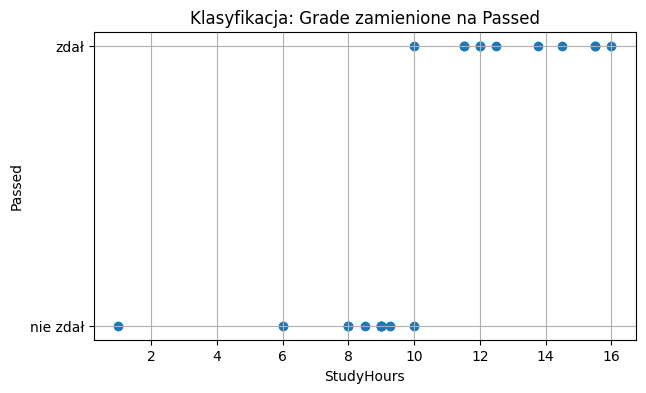

In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(grades['StudyHours'], grades['Passed'])
plt.xlabel('StudyHours')
plt.ylabel('Passed')
plt.title('Klasyfikacja: Grade zamienione na Passed')
plt.yticks([0, 1], ['nie zdał', 'zdał'])
plt.grid(True)
plt.show()


### Stop-klatka: czy regresja logistyczna to „regresja, która klasyfikuje”?

Tak, ale warto powiedzieć to precyzyjniej:

> **Regresja logistyczna jest modelem regresyjnym dla log-odds, który po dobraniu progu decyzyjnego może być użyty jako klasyfikator.**

Model nie zaczyna od twardej decyzji `zdał` / `nie zdał`. Najpierw liczy liniowy wynik:

$$
z = \beta_0 + \beta_1 x
$$

ten wynik zamienia przez funkcję sigmoid na prawdopodobieństwo:

$$
\hat p = \frac{1}{1 + e^{-z}}
$$

czyli w naszym przykładzie:

$$
\hat p = P(Passed = 1 \mid StudyHours)
$$

Dopiero na końcu wybieramy próg, np. $t=0.5$:

$$
\hat y =
\begin{cases}
1, & \hat p \ge 0.5 \\
0, & \hat p < 0.5
\end{cases}
$$

Dlatego dobrze rozdzielać trzy rzeczy:

| Obiekt | Co oznacza? | Typ wyniku |
|---|---|---|
| $z = \beta_0 + \beta_1 x$ | liniowy score modelu | dowolna liczba |
| $\hat p = \sigma(z)$ | prawdopodobieństwo klasy pozytywnej | liczba od 0 do 1 |
| $\hat y = I(\hat p \ge t)$ | decyzja po wybraniu progu | klasa 0 albo 1 |

To jest sedno wielu problemów klasyfikacyjnych: **model daje score albo prawdopodobieństwo, a decyzja zależy od progu i kosztów błędów**.

Poniższy mini-przykład jest celowo trochę „nieczysty”: są osoby, które uczą się mało i zdają, oraz osoby, które uczą się dużo i nie zdają. Dzięki temu pojawią się błędy typu FP/FN i będzie widać, po co nam confusion matrix.


beta_0 = -3.062
beta_1 = 0.340

Model liniowy na skali log-odds:
logit(p) = -3.062 + 0.340 * StudyHours

Granica decyzyjna dla progu 0.5: StudyHours ≈ 9.00


,Student,StudyHours,Passed,p_hat,pred_0_5,case
0,Ala,3,0,0.115,0,TN: nie zdał i model przewidział nie zdał
1,Bartek,5,0,0.204,0,TN: nie zdał i model przewidział nie zdał
2,Celina,7,1,0.336,0,"FN: model przewidział nie zdał, ale zdał"
3,Daniel,8,0,0.416,0,TN: nie zdał i model przewidział nie zdał
4,Ewa,9,1,0.500,1,TP: zdał i model przewidział zdał
5,Filip,10,0,0.585,1,"FP: model przewidział zdał, ale nie zdał"
6,Gosia,11,1,0.664,1,TP: zdał i model przewidział zdał
7,Hubert,12,1,0.736,1,TP: zdał i model przewidział zdał
8,Iza,13,0,0.796,1,"FP: model przewidział zdał, ale nie zdał"
9,Jan,14,1,0.846,1,TP: zdał i model przewidział zdał


,pred 0: nie zdał,pred 1: zdał
true 0: nie zdał,3,2
true 1: zdał,1,6


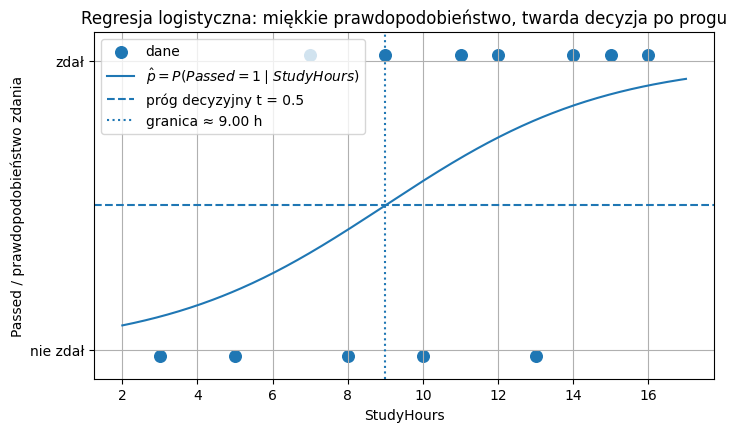

In [7]:

# Mini-przykład na boku: regresja logistyczna jako model prawdopodobieństwa
# Cel: zobaczyć różnicę między scorem, prawdopodobieństwem i twardą decyzją.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Dane dydaktyczne: jedna cecha StudyHours i binarny wynik Passed.
# Przykład jest celowo nieidealny: nie każda osoba z dużą liczbą godzin zdała
# i nie każda osoba z małą liczbą godzin nie zdała.
mini = pd.DataFrame({
    "Student": ["Ala", "Bartek", "Celina", "Daniel", "Ewa", "Filip",
                "Gosia", "Hubert", "Iza", "Jan", "Kasia", "Leon"],
    "StudyHours": [3, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
    "Passed":     [0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1]
})

X_mini = mini[["StudyHours"]]
y_mini = mini["Passed"]

# Regresja logistyczna uczy liniowy score:
# z = beta_0 + beta_1 * StudyHours
# a potem zamienia go na prawdopodobieństwo przez sigmoid.
logreg_mini = LogisticRegression()
logreg_mini.fit(X_mini, y_mini)

beta_0 = logreg_mini.intercept_[0]
beta_1 = logreg_mini.coef_[0, 0]

# Prawdopodobieństwo klasy 1, czyli Passed = 1.
mini["p_hat"] = logreg_mini.predict_proba(X_mini)[:, 1]

# Twarda decyzja przy progu 0.5.
mini["pred_0_5"] = (mini["p_hat"] >= 0.5).astype(int)

# Opisujemy typ wyniku w języku confusion matrix.
def case_type(row):
    if row["Passed"] == 1 and row["pred_0_5"] == 1:
        return "TP: zdał i model przewidział zdał"
    if row["Passed"] == 0 and row["pred_0_5"] == 0:
        return "TN: nie zdał i model przewidział nie zdał"
    if row["Passed"] == 0 and row["pred_0_5"] == 1:
        return "FP: model przewidział zdał, ale nie zdał"
    if row["Passed"] == 1 and row["pred_0_5"] == 0:
        return "FN: model przewidział nie zdał, ale zdał"

mini["case"] = mini.apply(case_type, axis=1)

print(f"beta_0 = {beta_0:.3f}")
print(f"beta_1 = {beta_1:.3f}")
print()
print("Model liniowy na skali log-odds:")
print(f"logit(p) = {beta_0:.3f} + {beta_1:.3f} * StudyHours")

# Granica decyzyjna dla progu 0.5.
# Dla p=0.5 mamy logit(p)=0, więc beta_0 + beta_1*x = 0.
decision_boundary = -beta_0 / beta_1
print()
print(f"Granica decyzyjna dla progu 0.5: StudyHours ≈ {decision_boundary:.2f}")

# Tabela predykcji.
display(mini[["Student", "StudyHours", "Passed", "p_hat", "pred_0_5", "case"]].round(3))

# Confusion matrix.
cm = confusion_matrix(y_mini, mini["pred_0_5"], labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["true 0: nie zdał", "true 1: zdał"],
    columns=["pred 0: nie zdał", "pred 1: zdał"]
)
display(cm_df)

# Wykres: punkty, krzywa prawdopodobieństwa i próg decyzyjny.
x_grid = np.linspace(mini["StudyHours"].min() - 1, mini["StudyHours"].max() + 1, 300)
X_grid = pd.DataFrame({"StudyHours": x_grid})
p_grid = logreg_mini.predict_proba(X_grid)[:, 1]

plt.figure(figsize=(8, 4.5))

# Małe przesunięcie punktów w pionie, żeby było je łatwiej zobaczyć.
y_jitter = np.where(mini["Passed"] == 1, 0.02, -0.02)
plt.scatter(mini["StudyHours"], mini["Passed"] + y_jitter, s=70, label="dane")

plt.plot(x_grid, p_grid, label=r"$\hat p = P(Passed=1 \mid StudyHours)$")
plt.axhline(0.5, linestyle="--", label="próg decyzyjny t = 0.5")
plt.axvline(decision_boundary, linestyle=":", label=f"granica ≈ {decision_boundary:.2f} h")

plt.ylim(-0.1, 1.1)
plt.yticks([0, 1], ["nie zdał", "zdał"])
plt.xlabel("StudyHours")
plt.ylabel("Passed / prawdopodobieństwo zdania")
plt.title("Regresja logistyczna: miękkie prawdopodobieństwo, twarda decyzja po progu")
plt.grid(True)
plt.legend()
plt.show()


## 5. Probability, odds i log-odds

Prawdopodobieństwo sukcesu oznaczamy jako:

$$
p = P(Y=1)
$$

Odds to stosunek sukcesu do porażki:

$$
odds = \frac{p}{1-p}
$$

Log-odds to logarytm odds:

$$
logit(p) = \log\left(\frac{p}{1-p}\right)
$$

Najważniejsza intuicja:

| Skala | Zakres | Interpretacja |
|---|---:|---|
| $p$ | $[0,1]$ | prawdopodobieństwo |
| $odds$ | $[0,\infty)$ | sukcesy względem porażek |
| $logit(p)$ | $(-\infty,\infty)$ | skala liniowa dla modelu |

In [8]:
probabilities = np.array([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
odds = probabilities / (1 - probabilities)
log_odds = np.log(odds)

pd.DataFrame({
    'p': probabilities,
    'odds=p/(1-p)': odds,
    'log_odds=log(odds)': log_odds,
})

,p,odds=p/(1-p),log_odds=log(odds)
0,0.01,0.010101,-4.595120
1,0.05,0.052632,-2.944439
2,0.10,0.111111,-2.197225
3,0.25,0.333333,-1.098612
4,0.50,1.000000,0.000000
5,0.75,3.000000,1.098612
6,0.90,9.000000,2.197225
7,0.95,19.000000,2.944439
8,0.99,99.000000,4.595120


### Co warto powiedzieć studentom?

Prawdopodobieństwo jest intuicyjne, ale ograniczone:

$$
0 \le p \le 1
$$

Linia prosta może wyjść poza ten zakres. Dlatego regresja logistyczna nie modeluje $p$ bezpośrednio jako linii. Modeluje liniowo **log-odds**:

$$
\log\left(\frac{p}{1-p}\right)=b_0+b_1x
$$

A potem wraca do prawdopodobieństwa przez sigmoid:

$$
p = \frac{1}{1+e^{-(b_0+b_1x)}}
$$


## 5A. Dlaczego pojawia się exponenta? Procent składany, ścieżki i odds

Wcześniej można było odnieść wrażenie, że robimy tylko formalną sztuczkę:

$$
z = \log(odds)
\quad \Rightarrow \quad
odds = e^z
$$

To algebraicznie jest prawda, ale dydaktycznie ważniejsze jest pytanie:

> **Dlaczego exponenta jest naturalna dla odds?**

Najkrótsza intuicja:

> exponenta pojawia się wtedy, gdy wiele małych efektów **mnoży się**, a nie dodaje.

To jest ta sama intuicja, która stoi za procentem składanym.

Jeżeli kapitał rośnie przez procent składany, to każdy krok mnoży aktualną wartość:

$$
K_{t+1} = K_t(1+r)
$$

Po wielu krokach:

$$
K(t)=K_0(1+r)^t
$$

A gdy składanie jest coraz drobniejsze i coraz częstsze, dostajemy granicę:

$$
e^x =
\lim_{n \to \infty}
\left(1+\frac{x}{n}\right)^n
$$

Czyli \(e^x\) można rozumieć jako **granicę wielu bardzo małych multiplikatywnych kroków**.

W regresji logistycznej podobnie nie składamy kapitału, tylko **odds**.

Jeżeli jedna jednostka cechy, np. jedna godzina nauki, daje skumulowany efekt \(\beta_1\) na skali log-odds, to odpowiadający mnożnik odds wynosi:

$$
e^{\beta_1}
$$

Czyli model:

$$
z = \beta_0 + \beta_1 x
$$

oznacza:

$$
odds(x)=e^z=e^{\beta_0+\beta_1x}
$$

a więc:

$$
odds(x)=e^{\beta_0}\left(e^{\beta_1}\right)^x
$$

To jest dokładnie analogia do procentu składanego:

$$
K(t)=K_0(1+r)^t
$$

Tylko zamiast kapitału \(K\) mamy odds.


In [9]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

beta = 0.5

n_values = np.array([1, 2, 5, 10, 50, 100, 1000, 10000])

compound_limit = pd.DataFrame({
    "liczba małych kroków n": n_values,
    r"(1 + beta/n)^n": (1 + beta / n_values) ** n_values,
    r"exp(beta)": np.exp(beta)
})

compound_limit.round(6)


,liczba małych kroków n,(1 + beta/n)^n,exp(beta)
0,1,1.500000,1.648721
1,2,1.562500,1.648721
2,5,1.610510,1.648721
3,10,1.628895,1.648721
4,50,1.644632,1.648721
5,100,1.646668,1.648721
6,1000,1.648515,1.648721
7,10000,1.648701,1.648721



### Jak czytać tę tabelę?

Ustawiamy:

$$
\beta = 0.5
$$

i patrzymy na:

$$
\left(1+\frac{\beta}{n}\right)^n
$$

Dla małego \(n\) mamy kilka większych kroków.  
Dla dużego \(n\) mamy bardzo wiele drobnych kroków.

Gdy:

$$
n \to \infty
$$

dostajemy:

$$
e^\beta
$$

Czyli \(e^\beta\) to granica bardzo częstego składania małych mnożników.

W języku odds:

> jeżeli efekt jednej jednostki cechy jest składany z wielu małych multiplikatywnych efektów, naturalnym mnożnikiem końcowym jest \(e^\beta\).


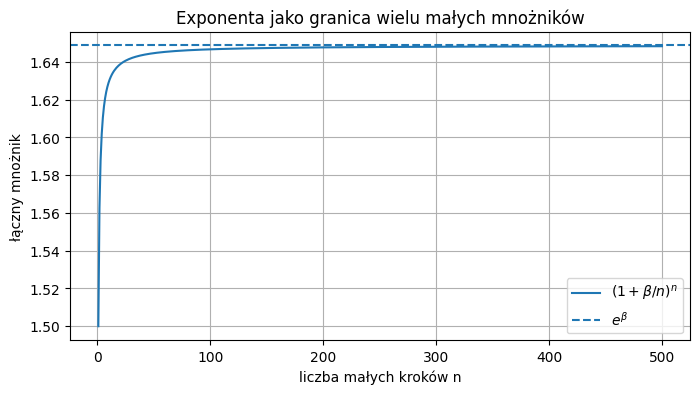

In [10]:

n_grid = np.arange(1, 501)
compound_values = (1 + beta / n_grid) ** n_grid

plt.figure(figsize=(8, 4))
plt.plot(n_grid, compound_values, label=r"$(1+\beta/n)^n$")
plt.axhline(np.exp(beta), linestyle="--", label=r"$e^\beta$")
plt.xlabel("liczba małych kroków n")
plt.ylabel("łączny mnożnik")
plt.title(r"Exponenta jako granica wielu małych mnożników")
plt.grid(True)
plt.legend()
plt.show()



### Intuicja ścieżek i kombinacji

Można też myśleć kombinatorycznie.

Jeżeli na każdym kroku mamy \(m\) możliwości, to po \(n\) krokach liczba ścieżek wynosi:

$$
m^n
$$

Na przykład decyzje tak/nie dają:

$$
2^n
$$

ścieżek.

To nie jest jeszcze regresja logistyczna, ale pokazuje ten sam mechanizm:

> kolejne kroki nie dodają możliwości, tylko je mnożą.

Możemy też zapisać:

$$
m^n = e^{n\log(m)}
$$

Czyli wzrost multiplikatywny można zapisać przez exponentę, a logarytm prostuje go do linii:

$$
\log(m^n)=n\log(m)
$$

Uwaga dydaktyczna:

Nie musimy tutaj wchodzić w formalne całki po ścieżkach.  
Wystarczy intuicja: jeżeli wiele lokalnych wyborów albo lokalnych wag się mnoży, to logarytm zamienia produkt w sumę, a exponenta wraca z sumy do produktu.

W regresji logistycznej \(z\) można myśleć jako **skumulowaną addytywną evidencję** za klasą pozytywną.  
Po exponentowaniu dostajemy dodatnią wagę/mnożnik:

$$
weight_1 = e^z
$$

Jeżeli klasie negatywnej damy wagę bazową:

$$
weight_0 = 1
$$

to:

$$
odds = \frac{weight_1}{weight_0}=e^z
$$

a prawdopodobieństwo klasy pozytywnej to znormalizowana waga:

$$
p = \frac{weight_1}{weight_0+weight_1}
=
\frac{e^z}{1+e^z}
=
\frac{1}{1+e^{-z}}
$$

To jest bardzo obrazowe:

> \(z\) jest sumą argumentów/evidencji,  
> \(e^z\) zamienia tę sumę na dodatnią wagę,  
> normalizacja zamienia wagę na prawdopodobieństwo.


In [11]:

steps = np.arange(0, 11)

paths = pd.DataFrame({
    "liczba kroków n": steps,
    "ścieżki binarne: 2^n": 2 ** steps,
    "ścieżki trójwyboru: 3^n": 3 ** steps,
    "log(2^n)": np.log(2 ** steps),
    "n * log(2)": steps * np.log(2),
    "log(3^n)": np.log(3 ** steps),
    "n * log(3)": steps * np.log(3),
})

paths.round(3)


,liczba kroków n,ścieżki binarne: 2^n,ścieżki trójwyboru: 3^n,log(2^n),n * log(2),log(3^n),n * log(3)
0,0,1,1,0.000,0.000,0.000,0.000
1,1,2,3,0.693,0.693,1.099,1.099
2,2,4,9,1.386,1.386,2.197,2.197
3,3,8,27,2.079,2.079,3.296,3.296
4,4,16,81,2.773,2.773,4.394,4.394
5,5,32,243,3.466,3.466,5.493,5.493
6,6,64,729,4.159,4.159,6.592,6.592
7,7,128,2187,4.852,4.852,7.690,7.690
8,8,256,6561,5.545,5.545,8.789,8.789
9,9,512,19683,6.238,6.238,9.888,9.888


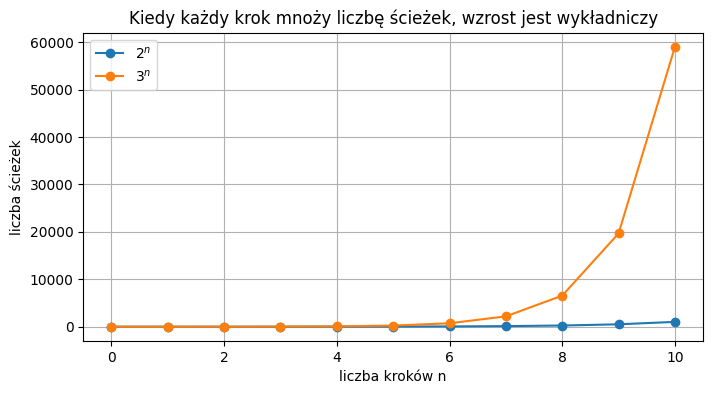

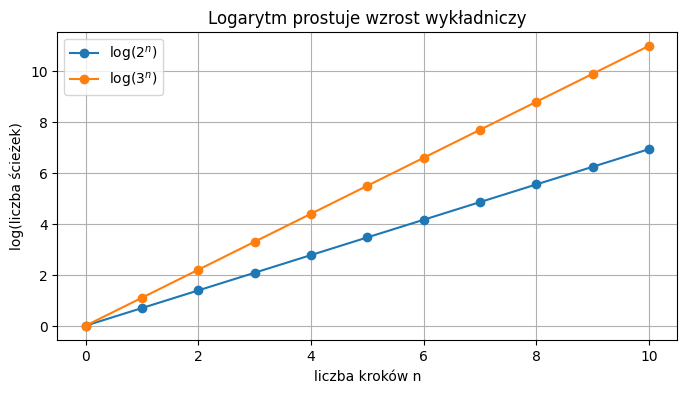

In [12]:

plt.figure(figsize=(8, 4))
plt.plot(paths["liczba kroków n"], paths["ścieżki binarne: 2^n"], marker="o", label=r"$2^n$")
plt.plot(paths["liczba kroków n"], paths["ścieżki trójwyboru: 3^n"], marker="o", label=r"$3^n$")
plt.xlabel("liczba kroków n")
plt.ylabel("liczba ścieżek")
plt.title("Kiedy każdy krok mnoży liczbę ścieżek, wzrost jest wykładniczy")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(paths["liczba kroków n"], paths["log(2^n)"], marker="o", label=r"$\log(2^n)$")
plt.plot(paths["liczba kroków n"], paths["log(3^n)"], marker="o", label=r"$\log(3^n)$")
plt.xlabel("liczba kroków n")
plt.ylabel("log(liczba ścieżek)")
plt.title("Logarytm prostuje wzrost wykładniczy")
plt.grid(True)
plt.legend()
plt.show()



### Najważniejszy most: od wag do prawdopodobieństwa

Poniższa tabelka pokazuje ten sam mechanizm już bezpośrednio dla regresji logistycznej.

Dla kilku wartości \(z\) liczymy:

$$
weight_1 = e^z
$$

$$
weight_0 = 1
$$

Następnie:

$$
odds = \frac{weight_1}{weight_0}
$$

oraz:

$$
p = \frac{weight_1}{weight_0+weight_1}
$$

Dzięki temu sigmoid przestaje wyglądać jak magiczny wzór.  
To jest po prostu normalizacja dwóch dodatnich wag:

- waga klasy 0: \(1\),
- waga klasy 1: \(e^z\).

Jeżeli \(z=0\), to:

$$
e^0=1
$$

czyli obie klasy mają takie same wagi:

$$
weight_0=1,\quad weight_1=1
$$

więc:

$$
p=\frac{1}{1+1}=0.5
$$


In [13]:

z_values = np.array([-4, -2, -1, 0, 1, 2, 4])

weight_0 = np.ones_like(z_values, dtype=float)
weight_1 = np.exp(z_values)

probability_from_weights = weight_1 / (weight_0 + weight_1)

weights_table = pd.DataFrame({
    "z = skumulowana evidence": z_values,
    "weight_0 = 1": weight_0,
    "weight_1 = exp(z)": weight_1,
    "odds = weight_1 / weight_0": weight_1 / weight_0,
    "p = weight_1 / (weight_0 + weight_1)": probability_from_weights
})

weights_table.round(3)


,z = skumulowana evidence,weight_0 = 1,weight_1 = exp(z),odds = weight_1 / weight_0,p = weight_1 / (weight_0 + weight_1)
0,-4,1.0,0.018,0.018,0.018
1,-2,1.0,0.135,0.135,0.119
2,-1,1.0,0.368,0.368,0.269
3,0,1.0,1.000,1.000,0.500
4,1,1.0,2.718,2.718,0.731
5,2,1.0,7.389,7.389,0.881
6,4,1.0,54.598,54.598,0.982



### Przykład z odds jako procentem składanym

Teraz wracamy do przykładu ze studentami.

Załóżmy, że dla \(x=0\) odds zdania wynoszą:

$$
odds_0 = 0.25
$$

czyli:

$$
p_0=\frac{0.25}{1+0.25}=0.20
$$

Załóżmy też, że każda dodatkowa godzina nauki daje efekt:

$$
\beta_1=0.5
$$

na skali log-odds.

Wtedy każda dodatkowa godzina mnoży odds przez:

$$
e^{0.5}\approx 1.65
$$

Czyli odds zachowują się jak procent składany:

$$
odds(x)=odds_0e^{0.5x}
$$

a log-odds są liniowe:

$$
\log(odds(x))=\log(odds_0)+0.5x
$$

To jest najważniejsza intuicja:

> odds rosną multiplikatywnie,  
> log-odds rosną liniowo,  
> prawdopodobieństwo rośnie sigmoidowo i nasyca się przy 1.


In [14]:

study_hours = np.arange(0, 9)

odds0 = 0.25
beta1 = 0.5

odds = odds0 * np.exp(beta1 * study_hours)
log_odds = np.log(odds)
p = odds / (1 + odds)

compound_odds_table = pd.DataFrame({
    "StudyHours": study_hours,
    "odds = odds0 * exp(beta1*x)": odds,
    "log_odds": log_odds,
    "p = odds / (1 + odds)": p,
    "mnożnik względem poprzedniego odds": pd.Series(odds).div(pd.Series(odds).shift(1))
})

compound_odds_table.round(3)


,StudyHours,odds = odds0 * exp(beta1*x),log_odds,p = odds / (1 + odds),mnożnik względem poprzedniego odds
0,0,0.250,-1.386,0.200,NaN
1,1,0.412,-0.886,0.292,1.649
2,2,0.680,-0.386,0.405,1.649
3,3,1.120,0.114,0.528,1.649
4,4,1.847,0.614,0.649,1.649
5,5,3.046,1.114,0.753,1.649
6,6,5.021,1.614,0.834,1.649
7,7,8.279,2.114,0.892,1.649
8,8,13.650,2.614,0.932,1.649


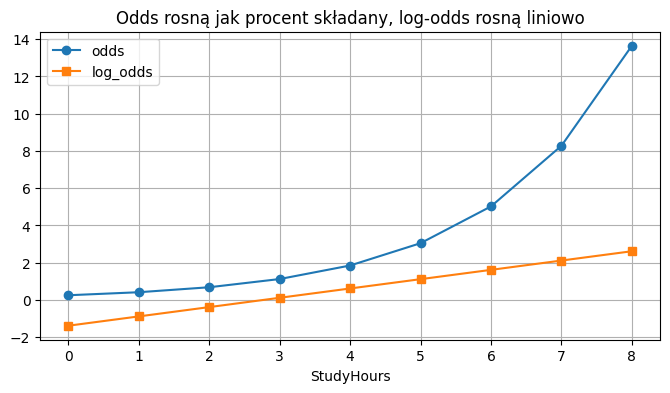

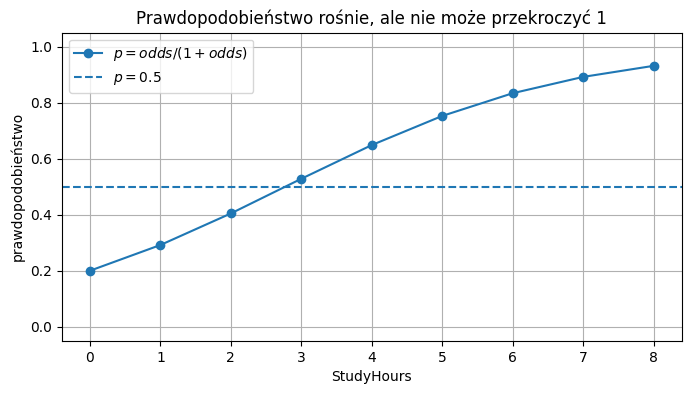

In [15]:

plt.figure(figsize=(8, 4))
plt.plot(study_hours, odds, marker="o", label="odds")
plt.plot(study_hours, log_odds, marker="s", label="log_odds")
plt.xlabel("StudyHours")
plt.title("Odds rosną jak procent składany, log-odds rosną liniowo")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(study_hours, p, marker="o", label=r"$p = odds/(1+odds)$")
plt.axhline(0.5, linestyle="--", label=r"$p=0.5$")
plt.xlabel("StudyHours")
plt.ylabel("prawdopodobieństwo")
plt.title("Prawdopodobieństwo rośnie, ale nie może przekroczyć 1")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()



### Co warto powiedzieć studentom?

Najlepsze krótkie podsumowanie:

> Exponenta jest naturalna, gdy efekty się mnożą.  
> Procent składany mnoży kapitał.  
> Kombinatoryka mnoży liczbę ścieżek.  
> Regresja logistyczna mnoży odds.

W regresji logistycznej:

$$
z=\beta_0+\beta_1x
$$

jest addytywną, liniową evidencją.

Exponenta zamienia ją na dodatnią wagę/mnożnik:

$$
e^z
$$

A normalizacja dwóch wag:

$$
weight_0=1,\quad weight_1=e^z
$$

daje prawdopodobieństwo:

$$
p=\frac{e^z}{1+e^z}
$$

czyli sigmoid.

To dlatego można myśleć o regresji logistycznej tak:

$$
\text{liniowa evidence}
\rightarrow
\text{multiplikatywne odds}
\rightarrow
\text{prawdopodobieństwo}
\rightarrow
\text{threshold}
\rightarrow
\text{decyzja}
$$



## 5B. Mini-lab StatQuest-style: krzywa logistyczna, likelihood i ROC na małych danych

W tym miejscu robimy bardzo mały przykład, który można policzyć częściowo **na papierze**, a częściowo sprawdzić kodem.

Chcemy zobaczyć całą ścieżkę:

$$
StudyHours \rightarrow z \rightarrow odds \rightarrow \hat p \rightarrow \hat y
$$

gdzie:

$$
z = \beta_0 + \beta_1 x
$$

$$
odds = e^z
$$

$$
\hat p = \frac{odds}{1+odds} = \frac{1}{1+e^{-z}}
$$

oraz decyzja przy progu $t$ to:

$$
\hat y = I(\hat p \ge t)
$$

**Idea ćwiczenia:**

1. ręcznie wybierzemy kilka krzywych logistycznych,
2. policzymy, jak dobrze przypisują prawdopodobieństwa prawdziwym klasom,
3. zobaczymy, że regresja logistyczna automatycznie znajduje współczynniki,
4. przejdziemy od prawdopodobieństw do macierzy pomyłek,
5. na końcu pokażemy ROC/AUC jako ocenę rankingu score'ów.

To jest bardzo ważna stop-klatka: **model daje score albo prawdopodobieństwo, a threshold dopiero robi decyzję.**


In [16]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, log_loss
)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Małe dane dydaktyczne: celowo nieidealne.
# Ktoś z mniejszą liczbą godzin może zdać, a ktoś z większą może nie zdać.
mini_statquest = pd.DataFrame({
    "Student": ["Ala", "Bartek", "Celina", "Daniel", "Ewa", "Filip", "Gosia", "Hubert"],
    "StudyHours": [2, 4, 6, 8, 10, 12, 14, 16],
    "Passed":     [0, 0, 1, 0, 1, 1, 0, 1]
})

mini_statquest


,Student,StudyHours,Passed
0,Ala,2,0
1,Bartek,4,0
2,Celina,6,1
3,Daniel,8,0
4,Ewa,10,1
5,Filip,12,1
6,Gosia,14,0
7,Hubert,16,1



### Krok 1: jedna ręcznie ustawiona krzywa

Załóżmy na chwilę, że model ma parametry:

$$
\beta_0 = -5
$$

$$
\beta_1 = 0.5
$$

czyli:

$$
z = -5 + 0.5 \cdot StudyHours
$$

Dla każdego studenta liczymy:

$$
z \rightarrow odds=e^z \rightarrow \hat p = \frac{odds}{1+odds}
$$

Potem liczymy, jak duże prawdopodobieństwo model przypisał **prawdziwemu zdarzeniu**:

$$
P(y_i \mid x_i) =
\begin{cases}
\hat p_i, & y_i=1 \\
1-\hat p_i, & y_i=0
\end{cases}
$$

To jest najprostsza intuicja likelihood: dobry model daje duże prawdopodobieństwo temu, co naprawdę się stało.


In [17]:

beta_0 = -5
beta_1 = 0.5

manual = mini_statquest.copy()
manual["z"] = beta_0 + beta_1 * manual["StudyHours"]
manual["odds = exp(z)"] = np.exp(manual["z"])
manual["p_hat = sigmoid(z)"] = sigmoid(manual["z"])

# Jeżeli student zdał, interesuje nas p_hat.
# Jeżeli nie zdał, interesuje nas 1 - p_hat.
manual["probability_of_true_class"] = np.where(
    manual["Passed"] == 1,
    manual["p_hat = sigmoid(z)"],
    1 - manual["p_hat = sigmoid(z)"]
)
manual["log_probability"] = np.log(manual["probability_of_true_class"])

likelihood = manual["probability_of_true_class"].prod()
log_likelihood = manual["log_probability"].sum()
mean_log_loss = -manual["log_probability"].mean()

print(f"Likelihood, czyli iloczyn prawdopodobieństw prawdziwych klas: {likelihood:.6f}")
print(f"Log-likelihood, czyli suma log-prawdopodobieństw: {log_likelihood:.3f}")
print(f"Mean log loss, czyli średnia kara: {mean_log_loss:.3f}")

manual[[
    "Student", "StudyHours", "Passed", "z", "odds = exp(z)",
    "p_hat = sigmoid(z)", "probability_of_true_class", "log_probability"
]].round(3)


Likelihood, czyli iloczyn prawdopodobieństw prawdziwych klas: 0.003383
Log-likelihood, czyli suma log-prawdopodobieństw: -5.689
Mean log loss, czyli średnia kara: 0.711


,Student,StudyHours,Passed,z,odds = exp(z),p_hat = sigmoid(z),probability_of_true_class,log_probability
0,Ala,2,0,-4.0,0.018,0.018,0.982,-0.018
1,Bartek,4,0,-3.0,0.050,0.047,0.953,-0.049
2,Celina,6,1,-2.0,0.135,0.119,0.119,-2.127
3,Daniel,8,0,-1.0,0.368,0.269,0.731,-0.313
4,Ewa,10,1,0.0,1.000,0.500,0.500,-0.693
5,Filip,12,1,1.0,2.718,0.731,0.731,-0.313
6,Gosia,14,0,2.0,7.389,0.881,0.119,-2.127
7,Hubert,16,1,3.0,20.086,0.953,0.953,-0.049



### Jak czytać tę tabelę?

Dla osoby, która naprawdę zdała ($y=1$), dobry model powinien dać duże $\hat p$.

Dla osoby, która naprawdę nie zdała ($y=0$), dobry model powinien dać małe $\hat p$, czyli duże $1-\hat p$.

Dlatego w kolumnie `probability_of_true_class` bierzemy:

- $\hat p$, jeśli `Passed = 1`,
- $1-\hat p$, jeśli `Passed = 0`.

Następnie:

$$
Likelihood = \prod_i P(y_i\mid x_i)
$$

W praktyce częściej używamy logarytmu:

$$
LogLikelihood = \sum_i \log P(y_i\mid x_i)
$$

A uczenie modelu logistycznego można rozumieć jako szukanie takich $\beta_0,\beta_1$, które zwiększają log-likelihood albo równoważnie zmniejszają log-loss.



### Krok 2: porównujemy kilka ręcznie ustawionych krzywych

Teraz porównamy trzy krzywe. Każda ma inną parę parametrów $\beta_0,\beta_1$.

To jest dobry moment na ćwiczenie na tablicy:

1. wybieramy jedną obserwację,
2. liczymy $z$,
3. liczymy $odds=e^z$,
4. liczymy $\hat p$,
5. sprawdzamy, czy model dał duże prawdopodobieństwo prawdziwej klasie.


In [18]:

candidate_models = [
    {"model": "A: łagodna krzywa",   "beta_0": -4.0, "beta_1": 0.35},
    {"model": "B: próg około 10h",    "beta_0": -5.0, "beta_1": 0.50},
    {"model": "C: ostrzejsza krzywa", "beta_0": -8.0, "beta_1": 0.80},
]

summary_rows = []
all_candidate_predictions = []

for cand in candidate_models:
    z = cand["beta_0"] + cand["beta_1"] * mini_statquest["StudyHours"]
    p = sigmoid(z)
    prob_true = np.where(mini_statquest["Passed"] == 1, p, 1 - p)
    log_prob = np.log(prob_true)
    pred = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(mini_statquest["Passed"], pred, labels=[0, 1]).ravel()
    
    summary_rows.append({
        "model": cand["model"],
        "beta_0": cand["beta_0"],
        "beta_1": cand["beta_1"],
        "boundary for t=0.5": -cand["beta_0"] / cand["beta_1"],
        "log_likelihood": log_prob.sum(),
        "mean_log_loss": -log_prob.mean(),
        "accuracy_t_0.5": accuracy_score(mini_statquest["Passed"], pred),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "AUC": roc_auc_score(mini_statquest["Passed"], p),
    })
    
    temp = mini_statquest.copy()
    temp["model"] = cand["model"]
    temp["z"] = z
    temp["p_hat"] = p
    temp["pred_t_0.5"] = pred
    all_candidate_predictions.append(temp)

candidate_summary = pd.DataFrame(summary_rows)
candidate_summary.round(3)


,model,beta_0,beta_1,boundary for t=0.5,log_likelihood,mean_log_loss,accuracy_t_0.5,TP,FP,TN,FN,AUC
0,A: łagodna krzywa,-4.0,0.35,11.429,-5.408,0.676,0.625,2,1,3,2,0.75
1,B: próg około 10h,-5.0,0.50,10.000,-5.689,0.711,0.750,3,1,3,1,0.75
2,C: ostrzejsza krzywa,-8.0,0.80,10.000,-7.559,0.945,0.750,3,1,3,1,0.75



### Ważna obserwacja

Najlepsza krzywa według `log_likelihood` / `mean_log_loss` to ta, która daje największe prawdopodobieństwo prawdziwym klasom.

Ale zwróć uwagę na coś subtelnego: jeżeli wszystkie modele są monotonicznie rosnącą funkcją `StudyHours`, to ranking studentów według score'u może być taki sam. Wtedy `AUC` może być takie samo, nawet jeśli prawdopodobieństwa są inaczej skalibrowane.

To prowadzi do ważnej różnicy:

- `log_loss` ocenia **jakość prawdopodobieństw**,
- `confusion matrix` ocenia **decyzje po wybranym progu**,
- `ROC/AUC` ocenia głównie **ranking score'ów** dla różnych progów.


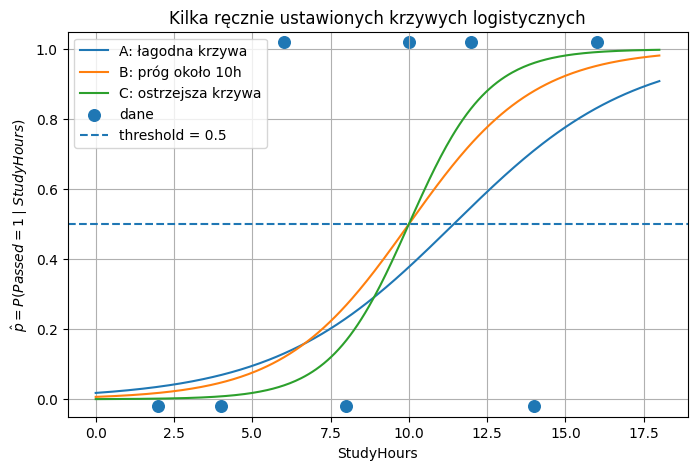

In [19]:

x_grid = np.linspace(0, 18, 300)

plt.figure(figsize=(8, 5))

for cand in candidate_models:
    z_grid = cand["beta_0"] + cand["beta_1"] * x_grid
    p_grid = sigmoid(z_grid)
    plt.plot(x_grid, p_grid, label=cand["model"])

# Punkty danych: 0/1 lekko przesunięte dla czytelności.
y_jitter = np.where(mini_statquest["Passed"] == 1, 0.02, -0.02)
plt.scatter(mini_statquest["StudyHours"], mini_statquest["Passed"] + y_jitter, s=70, label="dane")
plt.axhline(0.5, linestyle="--", label="threshold = 0.5")
plt.xlabel("StudyHours")
plt.ylabel(r"$\hat p = P(Passed=1 \mid StudyHours)$")
plt.title("Kilka ręcznie ustawionych krzywych logistycznych")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()



### Krok 3: regresja logistyczna znajduje krzywą automatycznie

Teraz pozwalamy `sklearn` dobrać współczynniki.

Ważne: model nadal ma ten sam kształt:

$$
logit(p)=\beta_0 + \beta_1 StudyHours
$$

ale wartości $\beta_0$ i $\beta_1$ są dobierane automatycznie tak, żeby dane były możliwie prawdopodobne według modelu.


In [20]:

X_small = mini_statquest[["StudyHours"]]
y_small = mini_statquest["Passed"]

# Duże C = słabsza regularyzacja, żeby łatwiej zobaczyć dopasowanie do małego przykładu.
auto_logreg = LogisticRegression(C=1000, max_iter=1000)
auto_logreg.fit(X_small, y_small)

b0_auto = auto_logreg.intercept_[0]
b1_auto = auto_logreg.coef_[0, 0]

mini_auto = mini_statquest.copy()
mini_auto["z_auto"] = b0_auto + b1_auto * mini_auto["StudyHours"]
mini_auto["p_hat_auto"] = auto_logreg.predict_proba(X_small)[:, 1]
mini_auto["pred_t_0.5"] = (mini_auto["p_hat_auto"] >= 0.5).astype(int)

print(f"beta_0 = {b0_auto:.3f}")
print(f"beta_1 = {b1_auto:.3f}")
print(f"granica dla threshold=0.5: {-b0_auto / b1_auto:.2f} godzin")
print(f"odds ratio dla +1 godziny: exp(beta_1) = {np.exp(b1_auto):.3f}")

mini_auto.round(3)


beta_0 = -1.949
beta_1 = 0.217
granica dla threshold=0.5: 9.00 godzin
odds ratio dla +1 godziny: exp(beta_1) = 1.242


,Student,StudyHours,Passed,z_auto,p_hat_auto,pred_t_0.5
0,Ala,2,0,-1.516,0.180,0
1,Bartek,4,0,-1.083,0.253,0
2,Celina,6,1,-0.650,0.343,0
3,Daniel,8,0,-0.217,0.446,0
4,Ewa,10,1,0.217,0.554,1
5,Filip,12,1,0.650,0.657,1
6,Gosia,14,0,1.083,0.747,1
7,Hubert,16,1,1.516,0.820,1



### Krok 4: prawdopodobieństwo to jeszcze nie macierz pomyłek

Macierz pomyłek powstaje dopiero po wybraniu progu, np.:

$$
t = 0.5
$$

Wtedy:

$$
\hat y_i = I(\hat p_i \ge 0.5)
$$

Dopiero teraz możemy policzyć:

$$
TP, FP, TN, FN
$$

oraz metryki takie jak accuracy, precision, recall i F1.


In [21]:

cm = confusion_matrix(y_small, mini_auto["pred_t_0.5"], labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["true 0: nie zdał", "true 1: zdał"],
    columns=["pred 0: nie zdał", "pred 1: zdał"]
)

tn, fp, fn, tp = cm.ravel()

metrics = pd.DataFrame([{
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp,
    "accuracy": accuracy_score(y_small, mini_auto["pred_t_0.5"]),
    "precision": precision_score(y_small, mini_auto["pred_t_0.5"], zero_division=0),
    "recall / TPR": recall_score(y_small, mini_auto["pred_t_0.5"], zero_division=0),
    "specificity / TNR": tn / (tn + fp),
    "FPR": fp / (fp + tn),
    "F1": f1_score(y_small, mini_auto["pred_t_0.5"], zero_division=0),
    "AUC": roc_auc_score(y_small, mini_auto["p_hat_auto"]),
    "log_loss": log_loss(y_small, mini_auto["p_hat_auto"]),
}])

print("Macierz pomyłek dla threshold = 0.5")
display(cm_df)

print("Metryki dla threshold = 0.5")
display(metrics.round(3))


Macierz pomyłek dla threshold = 0.5


,pred 0: nie zdał,pred 1: zdał
true 0: nie zdał,3,1
true 1: zdał,1,3


Metryki dla threshold = 0.5


,TN,FP,FN,TP,accuracy,precision,recall / TPR,specificity / TNR,FPR,F1,AUC,log_loss
0,3,1,1,3,0.75,0.75,0.75,0.75,0.25,0.75,0.75,0.592



### Krok 5: ROC ręcznie jako chodzenie po progach

ROC powstaje tak:

1. bierzemy score modelu, np. $\hat p$,
2. ustawiamy różne progi,
3. dla każdego progu liczymy macierz pomyłek,
4. z macierzy pomyłek liczymy:

$$
TPR = \frac{TP}{TP+FN}
$$

oraz:

$$
FPR = \frac{FP}{FP+TN}
$$

Na wykresie ROC rysujemy:

$$
(FPR, TPR)
$$

Czyli ROC nie jest jedną macierzą pomyłek. ROC jest śladem wielu macierzy pomyłek dla wielu progów.


In [22]:

# Ręczne przejście po progach: sortujemy obserwacje od największego p_hat do najmniejszego.
roc_walk = mini_auto[["Student", "StudyHours", "Passed", "p_hat_auto"]].sort_values(
    "p_hat_auto", ascending=False
).reset_index(drop=True)

rows = []

# Start: próg większy niż każdy score -> wszyscy przewidziani jako 0.
thresholds_to_check = [roc_walk["p_hat_auto"].max() + 0.01] + list(roc_walk["p_hat_auto"])

for threshold in thresholds_to_check:
    pred = (mini_auto["p_hat_auto"] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_small, pred, labels=[0, 1]).ravel()
    rows.append({
        "threshold": threshold,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "TPR = recall": tp / (tp + fn) if (tp + fn) else 0,
        "FPR": fp / (fp + tn) if (fp + tn) else 0,
    })

manual_roc_table = pd.DataFrame(rows)
manual_roc_table.round(3)


,threshold,TN,FP,FN,TP,TPR = recall,FPR
0,0.830,4,0,4,0,0.00,0.00
1,0.820,4,0,3,1,0.25,0.00
2,0.747,3,1,3,1,0.25,0.25
3,0.657,3,1,2,2,0.50,0.25
4,0.554,3,1,1,3,0.75,0.25
5,0.446,2,2,1,3,0.75,0.50
6,0.343,2,2,0,4,1.00,0.50
7,0.253,1,3,0,4,1.00,0.75
8,0.180,0,4,0,4,1.00,1.00


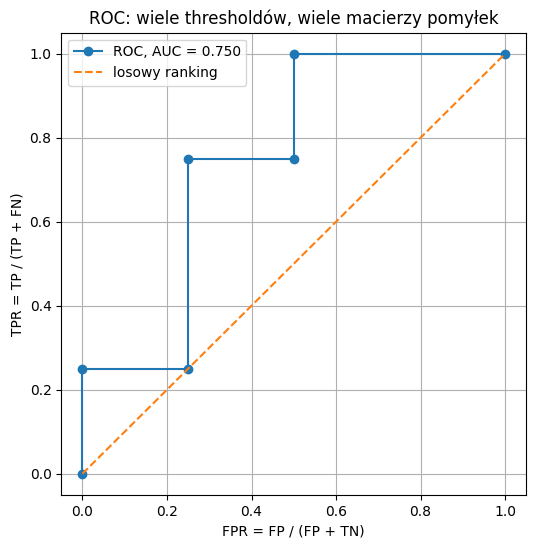

In [23]:

fpr, tpr, thresholds = roc_curve(y_small, mini_auto["p_hat_auto"])
auc_value = roc_auc_score(y_small, mini_auto["p_hat_auto"])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, marker="o", label=f"ROC, AUC = {auc_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="losowy ranking")
plt.xlabel("FPR = FP / (FP + TN)")
plt.ylabel("TPR = TP / (TP + FN)")
plt.title("ROC: wiele thresholdów, wiele macierzy pomyłek")
plt.grid(True)
plt.legend()
plt.show()



### Krok 6: AUC jako ranking — wersja do policzenia na papierze

AUC można zrozumieć bez całek.

Dla klasyfikacji binarnej:

> AUC to odsetek par `(pozytywny przykład, negatywny przykład)`, w których pozytywny przykład ma wyższy score niż negatywny przykład.

Czyli bierzemy wszystkie pary:

$$
(y=1, y=0)
$$

i sprawdzamy, czy:

$$
score_{positive} > score_{negative}
$$

Jeśli tak, model dobrze ustawił ranking tej pary.


In [24]:

positive_scores = mini_auto.loc[mini_auto["Passed"] == 1, ["Student", "p_hat_auto"]]
negative_scores = mini_auto.loc[mini_auto["Passed"] == 0, ["Student", "p_hat_auto"]]

pair_rows = []
for _, pos in positive_scores.iterrows():
    for _, neg in negative_scores.iterrows():
        if pos["p_hat_auto"] > neg["p_hat_auto"]:
            pair_score = 1.0
            result = "positive score > negative score"
        elif pos["p_hat_auto"] == neg["p_hat_auto"]:
            pair_score = 0.5
            result = "tie"
        else:
            pair_score = 0.0
            result = "positive score < negative score"
        pair_rows.append({
            "positive_student": pos["Student"],
            "positive_score": pos["p_hat_auto"],
            "negative_student": neg["Student"],
            "negative_score": neg["p_hat_auto"],
            "pair_score": pair_score,
            "result": result,
        })

pair_table = pd.DataFrame(pair_rows)
manual_auc = pair_table["pair_score"].mean()

print(f"AUC liczone ręcznie z par = {manual_auc:.3f}")
print(f"AUC ze sklearn              = {roc_auc_score(y_small, mini_auto['p_hat_auto']):.3f}")

pair_table.round(3)


AUC liczone ręcznie z par = 0.750
AUC ze sklearn              = 0.750


,positive_student,positive_score,negative_student,negative_score,pair_score,result
0,Celina,0.343,Ala,0.180,1.0,positive score > negative score
1,Celina,0.343,Bartek,0.253,1.0,positive score > negative score
2,Celina,0.343,Daniel,0.446,0.0,positive score < negative score
3,Celina,0.343,Gosia,0.747,0.0,positive score < negative score
4,Ewa,0.554,Ala,0.180,1.0,positive score > negative score
5,Ewa,0.554,Bartek,0.253,1.0,positive score > negative score
6,Ewa,0.554,Daniel,0.446,1.0,positive score > negative score
7,Ewa,0.554,Gosia,0.747,0.0,positive score < negative score
8,Filip,0.657,Ala,0.180,1.0,positive score > negative score
9,Filip,0.657,Bartek,0.253,1.0,positive score > negative score



### Co z tego zabrać dalej?

Ten mini-lab spina kilka tematów:

1. **Sigmoid** zamienia liniowy score $z$ na prawdopodobieństwo $\hat p$.
2. **Likelihood / log-loss** ocenia, czy prawdopodobieństwa są sensowne.
3. **Threshold** zamienia prawdopodobieństwa na decyzje.
4. **Confusion matrix** ocenia decyzje dla jednego thresholda.
5. **ROC** pokazuje, co dzieje się z TPR i FPR dla wielu thresholdów.
6. **AUC** ocenia ranking score'ów: czy pozytywne przykłady dostają wyższe score'y niż negatywne.

To jest bardzo dobra sekwencja przed właściwym blokiem o ROC/AUC:

$$
score \rightarrow threshold \rightarrow confusion\ matrix \rightarrow ROC \rightarrow AUC
$$


logit(p) = -16.103 + 1.559 * StudyHours
exp(b1) = 4.753


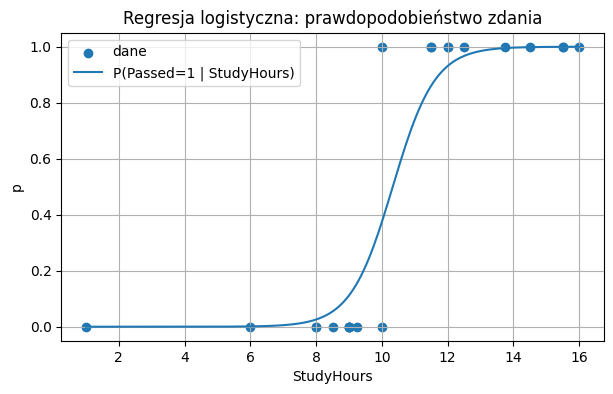

In [25]:
from sklearn.linear_model import LogisticRegression

X = grades[['StudyHours']]
y = grades['Passed']

logit_grade = LogisticRegression()
logit_grade.fit(X, y)

b0 = logit_grade.intercept_[0]
b1 = logit_grade.coef_[0, 0]

print(f'logit(p) = {b0:.3f} + {b1:.3f} * StudyHours')
print(f'exp(b1) = {np.exp(b1):.3f}')

x_grid = np.linspace(grades['StudyHours'].min(), grades['StudyHours'].max(), 200)
log_odds_grid = b0 + b1 * x_grid
p_grid = 1 / (1 + np.exp(-log_odds_grid))

plt.figure(figsize=(7, 4))
plt.scatter(grades['StudyHours'], grades['Passed'], label='dane')
plt.plot(x_grid, p_grid, label='P(Passed=1 | StudyHours)')
plt.xlabel('StudyHours')
plt.ylabel('p')
plt.title('Regresja logistyczna: prawdopodobieństwo zdania')
plt.legend()
plt.grid(True)
plt.show()

### Interpretacja współczynnika

Jeżeli:

$$
logit(p)=b_0+b_1x
$$

to wzrost $x$ o 1 zwiększa log-odds o $b_1$.

Na skali odds oznacza to mnożnik:

$$
\exp(b_1)
$$

Czyli przybliżona interpretacja brzmi:

> Każda dodatkowa godzina nauki mnoży odds zdania przez $\exp(b_1)$.

Na małych danych nie traktujemy tego jako silnego wniosku statystycznego. Traktujemy to jako intuicję modelu.

## 6. Threshold: probability to jeszcze nie decyzja

Model logistyczny zwraca prawdopodobieństwo:

$$
\hat p_i = P(Y_i=1\mid X_i)
$$

Ale aby dostać etykietę klasy, musimy wybrać próg:

$$
\hat y_i =
\begin{cases}
1, & \hat p_i \ge t \\
0, & \hat p_i < t
\end{cases}
$$

Najczęściej używa się $t=0.5$, ale to nie jest prawo matematyki. To decyzja praktyczna.

In [26]:
proba = logit_grade.predict_proba(X)[:, 1]

rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    pred = (proba >= t).astype(int)
    rows.append(classification_metrics(y, pred, f'threshold={t}'))

pd.DataFrame(rows)

,model,accuracy,precision,recall,f1
0,threshold=0.2,0.954545,0.916667,1.000000,0.956522
1,threshold=0.3,0.954545,0.916667,1.000000,0.956522
2,threshold=0.4,0.954545,1.000000,0.909091,0.952381
3,threshold=0.5,0.954545,1.000000,0.909091,0.952381
4,threshold=0.6,0.954545,1.000000,0.909091,0.952381
5,threshold=0.7,0.954545,1.000000,0.909091,0.952381
6,threshold=0.8,0.954545,1.000000,0.909091,0.952381


### Jak czytać progi?

- Niższy próg zwykle zwiększa `recall`, bo łatwiej przewidzieć klasę pozytywną.
- Wyższy próg zwykle zwiększa ostrożność modelu, ale może obniżyć `recall`.
- Threshold zależy od kosztów błędów.

Przykład praktyczny:

```text
Jeżeli fałszywy alarm jest tani, można obniżyć próg.
Jeżeli fałszywy alarm jest kosztowny, można podnieść próg.
```

## 7. Wersja nieczysta: po co nam naprawdę FP, FN i threshold?

Do tej pory używaliśmy danych, w których relacja między liczbą godzin nauki a zdaniem była prawie progowa. To jest dobre na start, bo łatwo zobaczyć ideę:

$$
StudyHours \uparrow \quad \Rightarrow \quad P(Passed=1) \uparrow
$$

Ale w prawdziwych danych granica rzadko jest idealna. Mogą istnieć osoby, które uczą się mało i zdają, oraz osoby, które uczą się dużo i nie zdają. Przyczyny mogą być poza naszym zbiorem cech: wcześniejsza wiedza, sen, stres, trudność testu, przypadek.

Dlatego teraz celowo tworzymy **nieczystą wersję danych**. To nie jest błąd — to eksperyment dydaktyczny. Chcemy zobaczyć, że:

$$
\text{prawdopodobieństwo} \neq \text{decyzja}
$$

oraz że ten sam model może mieć różne macierze pomyłek dla różnych progów decyzyjnych.

In [27]:
# Tworzymy dydaktyczną, "nieczystą" wersję danych.
# To NIE jest korekta oryginalnego zbioru, tylko celowe dodanie wyjątków,
# żeby zobaczyć FP/FN, wpływ progu i ograniczenia modeli.
extra_students = pd.DataFrame([
    {"Name": "Marta", "StudyHours": 7.5,  "Grade": 58.0},  # mało godzin, ale zdała
    {"Name": "Adam",  "StudyHours": 8.5,  "Grade": 55.0},  # mało godzin, ale zdał
    {"Name": "Tomek", "StudyHours": 9.5,  "Grade": 52.0},  # blisko granicy, zdał
    {"Name": "Nina",  "StudyHours": 10.5, "Grade": 49.0},  # blisko granicy, nie zdała
    {"Name": "Olek",  "StudyHours": 13.0, "Grade": 45.0},  # dużo godzin, ale nie zdał
    {"Name": "Ewa",   "StudyHours": 14.0, "Grade": 49.0},  # dużo godzin, ale nie zdała
])
extra_students["Passed"] = (extra_students["Grade"] >= 50).astype(int)
extra_students["source"] = "dodane wyjątki"

grades_noisy = grades[["Name", "StudyHours", "Grade", "Passed"]].copy()
grades_noisy["source"] = "oryginalne"
grades_noisy = pd.concat([grades_noisy, extra_students], ignore_index=True)
grades_noisy = grades_noisy.dropna(subset=["StudyHours", "Grade", "Passed"]).copy()
grades_noisy["Passed"] = grades_noisy["Passed"].astype(int)
grades_noisy = grades_noisy.sort_values("StudyHours").reset_index(drop=True)

display(grades_noisy)
print("Liczba obserwacji:", len(grades_noisy))
print("Rozkład klas:")
display(grades_noisy["Passed"].value_counts().rename(index={0: "nie zdał", 1: "zdał"}))

,Name,StudyHours,Grade,Passed,source
0,Vicky,1.00,3.0,0,oryginalne
1,Ismat,6.00,35.0,0,oryginalne
2,Marta,7.50,58.0,1,dodane wyjątki
3,Jakeem,8.00,27.0,0,oryginalne
4,Kian,8.00,15.0,0,oryginalne
5,Adam,8.50,55.0,1,dodane wyjątki
6,Rhonda,8.50,26.0,0,oryginalne
7,Naiyana,9.00,37.0,0,oryginalne
8,Helena,9.00,36.0,0,oryginalne
9,Pedro,9.00,47.0,0,oryginalne


Liczba obserwacji: 28
Rozkład klas:


Passed
nie zdał    14
zdał        14
Name: count, dtype: int64

### Ważna obserwacja: ta sama cecha może dawać różne klasy

Jeżeli dwie osoby mają bardzo podobne albo identyczne $X$, ale różne $y$, model oparty tylko na tej jednej cesze nie ma pełnej informacji.

Dla modelu używającego tylko `StudyHours` osoby o tej samej liczbie godzin są nierozróżnialne:

$$
X_i = X_j \quad \Rightarrow \quad \hat p_i = \hat p_j
$$

To nie musi oznaczać, że model jest „zły”. Czasem oznacza po prostu, że w danych brakuje ważnych cech.

In [28]:
# Szukamy sytuacji, w których ta sama liczba godzin ma różne wyniki.
# W oryginalnych danych jest to bardzo dobry przykład ograniczenia modelu z jedną cechą.
duplicated_hours = grades_noisy[grades_noisy.duplicated("StudyHours", keep=False)]
display(duplicated_hours.sort_values(["StudyHours", "Grade"]))

,Name,StudyHours,Grade,Passed,source
4,Kian,8.0,15.0,0,oryginalne
3,Jakeem,8.0,27.0,0,oryginalne
6,Rhonda,8.5,26.0,0,oryginalne
5,Adam,8.5,55.0,1,dodane wyjątki
8,Helena,9.0,36.0,0,oryginalne
7,Naiyana,9.0,37.0,0,oryginalne
10,Jimmie,9.0,42.0,0,oryginalne
9,Pedro,9.0,47.0,0,oryginalne
14,Anila,10.0,48.0,0,oryginalne
13,Dan,10.0,50.0,1,oryginalne


### Regresja logistyczna na danych nieidealnych

Regresja logistyczna nadal uczy się modelu:

$$
\log\left(\frac{p}{1-p}\right) = b_0 + b_1 \cdot StudyHours
$$

ale teraz nie oczekujemy idealnego rozdzielenia klas. Model zwraca miękkie predykcje $\hat p$, a błędy pojawiają się dopiero po wybraniu progu.

In [29]:
X_noisy = grades_noisy[["StudyHours"]]
y_noisy = grades_noisy["Passed"]

logit_noisy = LogisticRegression()
logit_noisy.fit(X_noisy, y_noisy)

b0_noisy = logit_noisy.intercept_[0]
b1_noisy = logit_noisy.coef_[0, 0]

print(f"logit(p) = {b0_noisy:.3f} + {b1_noisy:.3f} * StudyHours")
print(f"exp(b1) = {np.exp(b1_noisy):.3f}")

p_noisy = logit_noisy.predict_proba(X_noisy)[:, 1]
pred_05 = (p_noisy >= 0.5).astype(int)

results_noisy = grades_noisy[["Name", "StudyHours", "Grade", "Passed", "source"]].copy()
results_noisy["p_hat"] = p_noisy
results_noisy["pred_t_0_5"] = pred_05
results_noisy["error"] = results_noisy["Passed"] != results_noisy["pred_t_0_5"]

# Typ błędu z perspektywy klasy pozytywnej: Passed=1.
def error_type(row):
    if row["Passed"] == 0 and row["pred_t_0_5"] == 1:
        return "FP: przewidział zdał, ale nie zdał"
    if row["Passed"] == 1 and row["pred_t_0_5"] == 0:
        return "FN: przewidział nie zdał, ale zdał"
    if row["Passed"] == 1 and row["pred_t_0_5"] == 1:
        return "TP"
    return "TN"

results_noisy["case"] = results_noisy.apply(error_type, axis=1)
display(results_noisy.sort_values("StudyHours").round(3))

logit(p) = -4.810 + 0.456 * StudyHours
exp(b1) = 1.577


,Name,StudyHours,Grade,Passed,source,p_hat,pred_t_0_5,error,case
0,Vicky,1.00,3.0,0,oryginalne,0.013,0,False,TN
1,Ismat,6.00,35.0,0,oryginalne,0.111,0,False,TN
2,Marta,7.50,58.0,1,dodane wyjątki,0.199,0,True,"FN: przewidział nie zdał, ale zdał"
3,Jakeem,8.00,27.0,0,oryginalne,0.238,0,False,TN
4,Kian,8.00,15.0,0,oryginalne,0.238,0,False,TN
5,Adam,8.50,55.0,1,dodane wyjątki,0.281,0,True,"FN: przewidział nie zdał, ale zdał"
6,Rhonda,8.50,26.0,0,oryginalne,0.281,0,False,TN
7,Naiyana,9.00,37.0,0,oryginalne,0.330,0,False,TN
8,Helena,9.00,36.0,0,oryginalne,0.330,0,False,TN
9,Pedro,9.00,47.0,0,oryginalne,0.330,0,False,TN


In [30]:
cm_05 = confusion_matrix(y_noisy, pred_05, labels=[0, 1])
cm_05_df = pd.DataFrame(cm_05, index=["true 0: nie zdał", "true 1: zdał"], columns=["pred 0", "pred 1"])

display(cm_05_df)
display(pd.DataFrame([
    classification_metrics(y_noisy, pred_05, "LogisticRegression, threshold=0.5, dane nieczyste")
]))

print("Błędnie sklasyfikowane przypadki:")
display(results_noisy[results_noisy["error"]].sort_values("StudyHours").round(3))

,pred 0,pred 1
true 0: nie zdał,12,2
true 1: zdał,4,10


,model,accuracy,precision,recall,f1
0,"LogisticRegression, threshold=0.5, dane nieczyste",0.785714,0.833333,0.714286,0.769231


Błędnie sklasyfikowane przypadki:


,Name,StudyHours,Grade,Passed,source,p_hat,pred_t_0_5,error,case
2,Marta,7.5,58.0,1,dodane wyjątki,0.199,0,True,"FN: przewidział nie zdał, ale zdał"
5,Adam,8.5,55.0,1,dodane wyjątki,0.281,0,True,"FN: przewidział nie zdał, ale zdał"
12,Tomek,9.5,52.0,1,dodane wyjątki,0.382,0,True,"FN: przewidział nie zdał, ale zdał"
13,Dan,10.0,50.0,1,oryginalne,0.437,0,True,"FN: przewidział nie zdał, ale zdał"
21,Olek,13.0,45.0,0,dodane wyjątki,0.753,1,True,"FP: przewidział zdał, ale nie zdał"
23,Ewa,14.0,49.0,0,dodane wyjątki,0.827,1,True,"FP: przewidział zdał, ale nie zdał"


### Wykres: model jest miękki, decyzja jest twarda

Na wykresie krzywa pokazuje prawdopodobieństwo:

$$
\hat p = P(Passed=1 \mid StudyHours)
$$

Linia pozioma $t=0.5$ jest dopiero regułą decyzyjną. To znaczy, że model probabilistyczny i decyzja klasyfikacyjna to dwa osobne kroki.

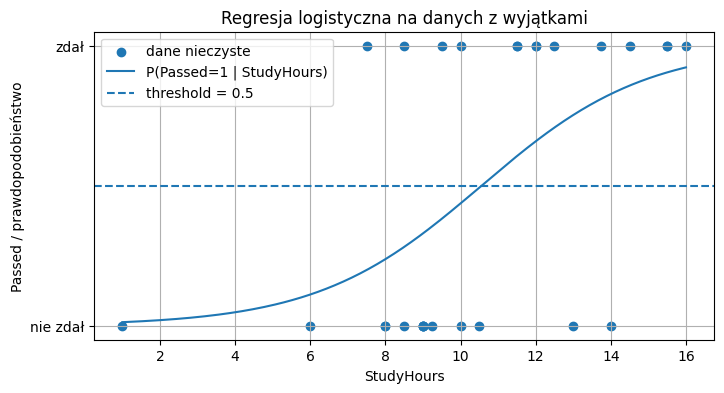

In [31]:
x_grid = np.linspace(grades_noisy["StudyHours"].min(), grades_noisy["StudyHours"].max(), 200)
log_odds_grid = b0_noisy + b1_noisy * x_grid
p_grid = 1 / (1 + np.exp(-log_odds_grid))

plt.figure(figsize=(8, 4))
plt.scatter(grades_noisy["StudyHours"], grades_noisy["Passed"], label="dane nieczyste")
plt.plot(x_grid, p_grid, label="P(Passed=1 | StudyHours)")
plt.axhline(0.5, linestyle="--", label="threshold = 0.5")
plt.xlabel("StudyHours")
plt.ylabel("Passed / prawdopodobieństwo")
plt.title("Regresja logistyczna na danych z wyjątkami")
plt.yticks([0, 1], ["nie zdał", "zdał"])
plt.legend()
plt.grid(True)
plt.show()

### Jeden model, wiele progów

Próg decyzyjny $t$ nie jest parametrem nauczonym przez regresję logistyczną. To nasza decyzja po modelowaniu.

$$
\hat y =
\begin{cases}
1, & \hat p \ge t \\
0, & \hat p < t
\end{cases}
$$

Niższy próg zwykle oznacza: łatwiej przewidzieć klasę pozytywną. Wtedy rośnie recall, ale może wzrosnąć liczba false positives.

Wyższy próg zwykle oznacza: model jest ostrożniejszy. Wtedy może spaść liczba false positives, ale może wzrosnąć liczba false negatives.

In [32]:
def threshold_report(y_true, score, thresholds, cost_fp=1, cost_fn=5):
    rows = []
    for t in thresholds:
        pred = (score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        rows.append({
            "threshold": t,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "accuracy": accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "cost": cost_fp * fp + cost_fn * fn,
        })
    return pd.DataFrame(rows)

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
threshold_table_noisy = threshold_report(y_noisy, p_noisy, thresholds, cost_fp=1, cost_fn=5)
display(threshold_table_noisy.round(3))

,threshold,TN,FP,FN,TP,accuracy,precision,recall,f1,cost
0,0.2,2,12,1,13,0.536,0.520,0.929,0.667,17
1,0.3,5,9,2,12,0.607,0.571,0.857,0.686,19
2,0.4,10,4,3,11,0.750,0.733,0.786,0.759,19
3,0.5,12,2,4,10,0.786,0.833,0.714,0.769,22
4,0.6,12,2,4,10,0.786,0.833,0.714,0.769,22
5,0.7,12,2,8,6,0.643,0.750,0.429,0.545,42
6,0.8,13,1,9,5,0.643,0.833,0.357,0.500,46


### Koszt błędów: dlaczego najlepszy próg nie musi mieć najwyższego accuracy?

Czasem jeden typ błędu jest droższy niż drugi. Możemy zapisać prosty koszt:

$$
Cost = C_{FP} \cdot FP + C_{FN} \cdot FN
$$

Dla przykładu powyżej ustawiliśmy $C_{FP}=1$ oraz $C_{FN}=5$. To znaczy, że fałszywy negatyw jest pięć razy bardziej kosztowny niż fałszywy pozytyw.

W praktyce wybór progu zależy więc od celu zadania, a nie tylko od jednej metryki.

### Separowalność i regularyzacja

Gdy dane są prawie idealnie separowalne, regresja logistyczna może próbować ustawiać bardzo duże współczynniki, żeby prawdopodobieństwa były bardzo blisko 0 albo 1.

W `sklearn` domyślnie używana jest regularyzacja. Parametr `C` działa odwrotnie do siły kary:

- małe `C` $\Rightarrow$ silniejsza regularyzacja,
- duże `C` $\Rightarrow$ słabsza regularyzacja.

To dobry moment, żeby zauważyć, że nawet prosty model liniowy ma założenia i parametry, które wpływają na zachowanie granicy.

In [33]:
rows = []
for C in [0.01, 0.1, 1, 10, 100]:
    model_C = LogisticRegression(C=C, max_iter=1000)
    model_C.fit(X_noisy, y_noisy)
    b0_C = model_C.intercept_[0]
    b1_C = model_C.coef_[0, 0]
    p_C = model_C.predict_proba(X_noisy)[:, 1]
    pred_C = (p_C >= 0.5).astype(int)
    rows.append({
        "C": C,
        "b0": b0_C,
        "b1": b1_C,
        "exp(b1)": np.exp(b1_C),
        "accuracy": accuracy_score(y_noisy, pred_C),
        "f1": f1_score(y_noisy, pred_C),
    })

pd.DataFrame(rows).round(3)

,C,b0,b1,exp(b1),accuracy,f1
0,0.01,-1.443,0.137,1.147,0.786,0.769
1,0.10,-3.739,0.354,1.425,0.786,0.769
2,1.00,-4.810,0.456,1.577,0.786,0.769
3,10.00,-4.975,0.471,1.602,0.786,0.769
4,100.00,-4.993,0.473,1.605,0.786,0.769


## 8. Krótka zapowiedź modeli granic: logistic, LDA i QDA

W tym notebooku LDA traktujemy tylko jako zapowiedź. Pełniejsze porównanie LDA/QDA/KNN/SVM pojawi się w atlasie granic.

Dlaczego nie robimy pełnego LDA/QDA teraz?

Bo LDA/QDA wymagają dodatkowej intuicji geometryczno-statystycznej:

$$
p(x \mid y=k), \quad \mu_k, \quad \Sigma_k, \quad \text{kowariancja}, \quad \text{Bayes}
$$

Na tym etapie najważniejsze jest zrozumienie:

$$
\hat p \rightarrow threshold \rightarrow FP/FN
$$

oraz przejście do drzew:

$$
threshold \rightarrow split \rightarrow tree
$$

## 8. Krótki most: LDA jako inny liniowy klasyfikator

Regresja logistyczna modeluje bezpośrednio:

$$
P(Y=1\mid X)
$$

LDA, czyli **Linear Discriminant Analysis**, zaczyna od innego pytania:

> Jak wyglądają rozkłady cech w każdej klasie?

Dla dwóch klas LDA zakłada w uproszczeniu, że:

$$
X\mid Y=0 \sim \mathcal{N}(\mu_0, \Sigma)
$$

$$
X\mid Y=1 \sim \mathcal{N}(\mu_1, \Sigma)
$$

Ważne jest założenie wspólnej macierzy kowariancji $\Sigma$. Z tego założenia wynika **liniowa granica decyzyjna**.

Dlatego LDA jest dobrym mostem do kolejnych tematów:

$$
\text{regresja logistyczna} \leftrightarrow \text{LDA} \leftrightarrow \text{SVM}
$$

Wszystkie mogą dawać liniowe granice, ale dochodzą do nich inną drogą.

In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X, y)
lda_pred = lda.predict(X)
logit_pred = logit_grade.predict(X)

pd.DataFrame([
    classification_metrics(y, logit_pred, 'LogisticRegression na grades'),
    classification_metrics(y, lda_pred, 'LDA na grades'),
])

,model,accuracy,precision,recall,f1
0,LogisticRegression na grades,0.954545,1.0,0.909091,0.952381
1,LDA na grades,0.954545,1.0,0.909091,0.952381


### Co zapamiętać o LDA?

LDA jest modelem klasyfikacyjnym, ale ma bardziej statystyczną interpretację niż KNN czy drzewa.

- Regresja logistyczna modeluje $P(Y\mid X)$.
- LDA modeluje $P(X\mid Y)$ i priory klas.
- Przy swoich założeniach daje liniową granicę decyzyjną.

Na kolejnych zajęciach ważniejsze będą jednak drzewa i modele geometryczne. LDA możemy traktować jako krótki punkt odniesienia.

## Stop-klatka dydaktyczna: trzy rodzaje „liniowości”

Warto zatrzymać się na słowie „liniowy”, bo w różnych miejscach znaczy ono coś trochę innego.

W regresji liniowej model jest liniowy na skali targetu:

$$
\hat y = b_0 + b_1x
$$

W regresji logistycznej model jest liniowy na skali log-odds:

$$
logit(p)=b_0+b_1x
$$

Natomiast prawdopodobieństwo po przejściu przez sigmoid nie jest liniową funkcją $x$:

$$
p = \frac{1}{1+e^{-(b_0+b_1x)}}
$$

To bardzo dobrze łączy się z Twoją obserwacją z wykładu: logarytm „prostuje” skalę ilorazów i zamienia mnożenie na dodawanie. Dlatego modele liniowe często są liniowe dopiero po odpowiedniej transformacji skali.

## Typowe pytania studentów

**Czy $R^2$ to korelacja?**  
Nie. $R^2$ to współczynnik determinacji. W prostej regresji liniowej z jedną cechą i interceptem zachodzi związek $R^2=r^2$, ale ogólnie lepiej myśleć o $R^2$ jako o porównaniu modelu z baseline'em.

**Czy regresja logistyczna jest regresją czy klasyfikacją?**  
Nazwa historycznie pochodzi od modelowania ciągłej skali log-odds. W praktyce używamy jej najczęściej do klasyfikacji binarnej, bo po sigmoidalnym przekształceniu dostajemy prawdopodobieństwo klasy.

**Czy próg 0.5 jest zawsze najlepszy?**  
Nie. Próg 0.5 jest domyślny i wygodny, ale może być zły, jeśli klasy są niezbalansowane albo koszty błędów są różne.

**Czy LDA jest potrzebne, jeśli znamy regresję logistyczną?**  
LDA daje inną perspektywę: zamiast modelować $P(Y\mid X)$ bezpośrednio, modeluje rozkłady $X\mid Y$. Jest dobrym mostem między statystyką a geometrią klasyfikacji.

## Mini-zadania do omówienia ustnie

1. Jeżeli baseline przewiduje każdemu studentowi 60 punktów, a model przewiduje wartości bardzo bliskie prawdziwym ocenom, który błąd będzie mniejszy: $TSS$ czy $RSS$?

2. Co oznacza sytuacja, w której $R^2=0$ na zbiorze testowym?

3. Dlaczego $\hat p=0.8$ nie musi oznaczać, że przewidujemy klasę 1, jeśli próg decyzyjny ustawimy na $t=0.9$?

4. Co się dzieje z odds, gdy $p=0.5$?

5. Dlaczego $\log(OR)$ jest symetryczniejsze interpretacyjnie niż samo $OR$?

Te pytania są krótkie, ale bardzo dobrze sprawdzają, czy student rozumie różnicę między skalą predykcji, skalą prawdopodobieństwa i skalą decyzji.

## Ćwiczenie koncepcyjne na koniec

Przed przejściem do kolejnego tematu warto poprosić studentów o odpowiedź bez kodu:

1. Jaki jest najprostszy model odniesienia dla tego problemu?
2. Która część algorytmu jest „uczeniem”, a która jest tylko transformacją danych?
3. Który parametr kontroluje złożoność modelu?
4. Co mogłoby spowodować leakage w tym przykładzie?
5. Jaką metryką sprawdzimy, czy model naprawdę działa na danych niewidzianych?

Taki checkpoint pomaga utrwalić, że algorytm jest tylko jednym elementem większego eksperymentu ML:

$$
\text{definicja problemu} \rightarrow \text{pipeline} \rightarrow \text{model} \rightarrow \text{walidacja} \rightarrow \text{interpretacja}
$$

## 9. Checklista po tym notebooku

Po tej części student powinien umieć powiedzieć:

1. Czym różni się $\bar y$ od $\hat y$.
2. Dlaczego baseline przewidujący średnią jest potrzebny.
3. Co porównuje $R^2$.
4. Dlaczego klasyfikacja logistyczna używa log-odds.
5. Dlaczego probability nie jest jeszcze decyzją.
6. Dlaczego threshold zależy od problemu.
7. Jak LDA pasuje do rodziny liniowych klasyfikatorów.

Najkrótsze zdanie podsumowujące:

> Najpierw uczymy model zwracać sensowne liczby, potem decydujemy, jak tych liczb używać.

# Appendix: mini-most do drzew — próg jako granica decyzyjna

W jednej zmiennej granica decyzyjna jest bardzo prosta. Jeżeli mamy tylko `StudyHours`, to reguła:

$$
StudyHours \ge 10
$$

dzieli oś na dwa regiony:

```text
mniej niż 10 godzin      co najmniej 10 godzin
-------------------|----------------------------
                   10
```

Drzewo decyzyjne będzie robiło dokładnie tego typu pytania:

$$
x_j \le c?
$$

Różnica jest taka, że próg $c$ nie będzie wybrany ręcznie, tylko przez minimalizację nieczystości po podziale.

In [35]:
# Krótka demonstracja: ręczny threshold jako decyzja
# Ten fragment można pominąć, jeśli temat był już dobrze zrobiony na wykładzie.

demo_thresholds = [8, 9, 10, 11, 12]
demo_rows = []

for t in demo_thresholds:
    pred = (grades["StudyHours"] >= t).astype(int)
    true = grades["Passed"].astype(int)
    tn, fp, fn, tp = confusion_matrix(true, pred).ravel()
    demo_rows.append({
        "threshold_hours": t,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "accuracy": accuracy_score(true, pred),
        "recall": recall_score(true, pred, zero_division=0),
    })

pd.DataFrame(demo_rows).round(3)

,threshold_hours,TN,FP,FN,TP,accuracy,recall
0,8,2,9,0,11,0.591,1.000
1,9,5,6,0,11,0.727,1.000
2,10,10,1,0,11,0.955,1.000
3,11,11,0,1,10,0.955,0.909
4,12,11,0,3,8,0.864,0.727
